<a href="https://colab.research.google.com/github/mateuszlampert/agh-stochastic-ml/blob/sol%2Flab1/lab1_new/instructions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: Understanding Deep Learning Requires Rethinking Generalization

### Introduction

This lab is based on the paper ["Understanding Deep Learning Requires Rethinking Generalization"](https://arxiv.org/abs/1611.03530) by Zhang et al. (ICLR 2017). The paper presents a striking observation: deep neural networks can easily memorize training data with **completely random labels**, achieving near-perfect training accuracy while (unsurprisingly) failing to generalize.

This challenges classical learning theory, which suggests that models with enough capacity to memorize noise should generalize poorly even on real data. Yet in practice, the same overparameterized networks generalize remarkably well on true labels.

### Objectives

1. Observe that overparameterized networks achieve near-perfect training accuracy on MNIST
2. Demonstrate that the same network can memorize **random labels** (zero generalization)
3. Investigate the effect of **model capacity** (hidden size) on training and generalization
4. Test whether **weight decay regularization** can prevent memorization or improve generalization
5. Discuss what these results mean for classical generalization theory

### Setup

We begin by importing the necessary libraries and preparing the MNIST dataset. We use a **10,000-sample subset** of the training data — this keeps training fast while still being sufficient to demonstrate the generalization phenomena from the paper (the model is heavily overparameterized relative to the dataset size). The device is auto-detected to work on CUDA, MPS (Apple Silicon), or CPU.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

# Auto-detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

transform = transforms.Compose([transforms.ToTensor()])
batch_size = 256

full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

# Use a 10k subset for training — fast and still heavily overparameterized
subset_size: int = 10_000
train_dataset = Subset(full_train_dataset, list(range(subset_size)))

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]

Training samples: 10000, Test samples: 10000


### Explore the Data

Let's visualize a few samples from the MNIST dataset to understand what we're working with.

Batch shape: torch.Size([256, 1, 28, 28])
Target shape: torch.Size([256])


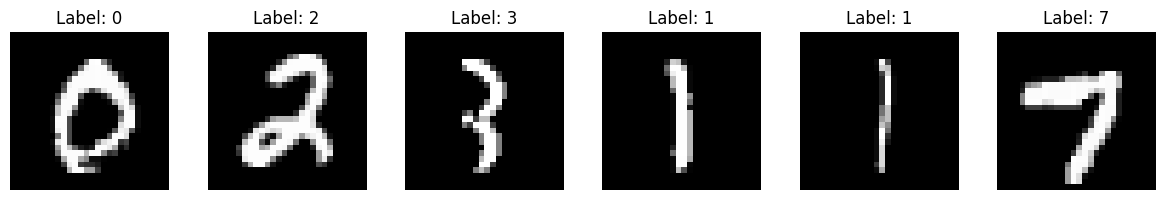

In [2]:
examples = iter(train_loader)
example_data, example_targets = next(examples)

print(f"Batch shape: {example_data.shape}")  # [batch_size, channels, height, width]
print(f"Target shape: {example_targets.shape}")  # [batch_size]

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(example_data[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {example_targets[i].item()}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Exercise 1: Define the Model

Implement a 3-layer MLP (Multi-Layer Perceptron) for MNIST classification. The architecture should be:

- **Input**: Flattened 28×28 image → 784 features
- **Hidden layer 1**: Linear(784, hidden_size) + ReLU
- **Hidden layer 2**: Linear(hidden_size, hidden_size) + ReLU
- **Output layer**: Linear(hidden_size, 10)

The `hidden_size` parameter controls model capacity — we will experiment with different values later.

In [3]:
class Net(nn.Module):
    def __init__(
        self, input_size: int = 784, hidden_size: int = 1024, num_classes: int = 10
    ) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=input_size, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.flatten(input=x, start_dim=1, end_dim=-1)
        return self.model(x)

### Training Utilities

The following helper functions are provided for training and evaluation. The `train_model` function:
1. Creates a `Net` with the specified `hidden_size`
2. Trains using Adam optimizer with cross-entropy loss
3. Tracks both **train** and **test** accuracy after each epoch
4. Returns the accuracy histories for plotting

In [4]:
def evaluate(model: nn.Module, data_loader: DataLoader) -> float:
    """Compute accuracy on a dataset."""
    model.eval()
    correct: int = 0
    total: int = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs: torch.Tensor = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


def train_model(
    train_loader: DataLoader,
    test_loader: DataLoader,
    hidden_size: int = 1024,
    num_epochs: int = 10,
    weight_decay: float = 0.0,
) -> tuple[list[float], list[float], nn.Module]:
    """Train a Net and return (train_accuracies, test_accuracies, model)."""
    model: nn.Module = Net(hidden_size=hidden_size).to(device)
    criterion: nn.Module = nn.CrossEntropyLoss()
    optimizer: optim.Optimizer = optim.Adam(
        model.parameters(), lr=1e-3, weight_decay=weight_decay
    )

    train_accuracies: list[float] = []
    test_accuracies: list[float] = []

    for epoch in range(num_epochs):
        model.train()
        running_loss: float = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs: torch.Tensor = model(images)
            loss: torch.Tensor = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss: float = running_loss / len(train_loader)
        train_acc: float = evaluate(model, train_loader)
        test_acc: float = evaluate(model, test_loader)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, "
            f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}"
        )

    return train_accuracies, test_accuracies, model

### Exercise 2: Train on True Labels

Train the model on the original MNIST labels using `hidden_size=1024` and `num_epochs=5`. Store the results and plot the train/test accuracy curves.

**Task:**
1. Call `train_model` with the true-label data loaders
2. Plot train accuracy and test accuracy vs. epoch on the same axes
3. Observe: does the model generalize well?

In [5]:
train_accs, test_accs, model = train_model(
    train_loader=train_loader,
    test_loader=test_loader,
    hidden_size=1024,
    num_epochs=5
)

Epoch [1/5], Loss: 0.6913, Train Acc: 0.9192, Test Acc: 0.9066
Epoch [2/5], Loss: 0.2641, Train Acc: 0.9451, Test Acc: 0.9264
Epoch [3/5], Loss: 0.1752, Train Acc: 0.9651, Test Acc: 0.9383
Epoch [4/5], Loss: 0.1193, Train Acc: 0.9767, Test Acc: 0.9463
Epoch [5/5], Loss: 0.0913, Train Acc: 0.9853, Test Acc: 0.9520


**Answer:** the model generalizes well and we do not observe overfitting during these 5 epochs of training. Both train and test accuracy are increasing, which suggests that model is learning general features instead of memorizing specific examples.

### Exercise 3: Random Labels Experiment

This is the **key experiment** from the paper. We replace the true labels with **completely random labels** drawn uniformly from {0, 1, ..., 9}. Since the labels have no correlation with the images, a model that achieves high training accuracy is simply **memorizing** the dataset.

**Task:**
1. Implement the `RandomLabels` dataset wrapper below
2. Create data loaders with random labels (wrap the existing `train_dataset`)
3. Train the model for **25 epochs** (memorization takes longer than learning true patterns)
4. Observe: can the network memorize random labels? What happens to test accuracy?

In [6]:
class RandomLabels(Dataset):
    """Wraps a dataset and replaces labels with random ones."""

    def __init__(self, base_dataset: Dataset, num_classes: int = 10, seed: int = 42) -> None:
        self.base: Dataset = base_dataset
        generator = torch.Generator().manual_seed(seed)
        self.random_labels = torch.randint(
            low=0,
            high=num_classes,
            size=(base_dataset.__len__(),),
            generator=generator
        )

    def __len__(self) -> int:
        return len(self.base)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        return self.base.__getitem__(idx)[0], self.random_labels[idx]

In [7]:
random_train_dataset = RandomLabels(
    base_dataset=train_dataset,
)
random_test_dataset = RandomLabels(
    base_dataset=test_dataset,
)

random_train_loader = DataLoader(dataset=random_train_dataset, batch_size=batch_size, shuffle=True)
random_test_loader = DataLoader(dataset=random_test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
random_train_accs, random_test_accs, random_model = train_model(
    train_loader=random_train_loader,
    test_loader=random_test_loader,
    hidden_size=1024,
    num_epochs=25
)

Epoch [1/25], Loss: 2.3059, Train Acc: 0.1267, Test Acc: 0.1033
Epoch [2/25], Loss: 2.2966, Train Acc: 0.1496, Test Acc: 0.1008
Epoch [3/25], Loss: 2.2851, Train Acc: 0.1675, Test Acc: 0.1038
Epoch [4/25], Loss: 2.2643, Train Acc: 0.1843, Test Acc: 0.0996
Epoch [5/25], Loss: 2.2330, Train Acc: 0.2134, Test Acc: 0.1006
Epoch [6/25], Loss: 2.1870, Train Acc: 0.2461, Test Acc: 0.1031
Epoch [7/25], Loss: 2.1218, Train Acc: 0.2886, Test Acc: 0.1028
Epoch [8/25], Loss: 2.0382, Train Acc: 0.3416, Test Acc: 0.1018
Epoch [9/25], Loss: 1.9277, Train Acc: 0.3949, Test Acc: 0.0998
Epoch [10/25], Loss: 1.8113, Train Acc: 0.4330, Test Acc: 0.1076
Epoch [11/25], Loss: 1.6832, Train Acc: 0.4963, Test Acc: 0.1013
Epoch [12/25], Loss: 1.5343, Train Acc: 0.5599, Test Acc: 0.1006
Epoch [13/25], Loss: 1.3953, Train Acc: 0.6061, Test Acc: 0.1024
Epoch [14/25], Loss: 1.2693, Train Acc: 0.6339, Test Acc: 0.1027
Epoch [15/25], Loss: 1.1528, Train Acc: 0.6830, Test Acc: 0.1026
Epoch [16/25], Loss: 1.0582, Train

**Answer:** the model can memorize random labels - train accuracy is increasing, while test accuracy stays at around 10%, which suggests that model is guessing one of 10 available labels - the network just memorized specific examples and did not learn any general patterns.

### Exercise 4: Comparison Plot

Create a side-by-side comparison of training on **true labels** vs. **random labels**.

**Task:**
1. Create a figure with 2 subplots
2. Left subplot: true labels — plot train accuracy, test accuracy, and generalization gap
3. Right subplot: random labels — plot train accuracy, test accuracy, and generalization gap
4. The **generalization gap** is defined as `train_accuracy - test_accuracy`

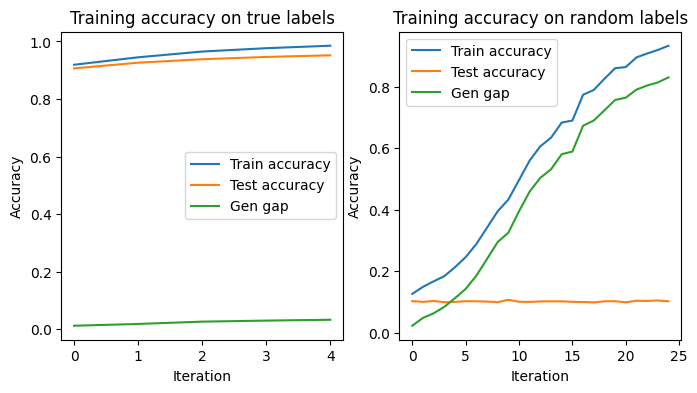

In [9]:
gen_gaps = [train_acc - test_acc for (train_acc, test_acc) in zip(train_accs, test_accs)]
random_gen_gaps = [random_train_acc - random_test_acc for (random_train_acc, random_test_acc) in zip(random_train_accs, random_test_accs)]

fix, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
axes[0].plot(train_accs, label="Train accuracy")
axes[0].plot(test_accs, label="Test accuracy")
axes[0].plot(gen_gaps, label="Gen gap")
axes[0].set_title("Training accuracy on true labels")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(random_train_accs, label="Train accuracy")
axes[1].plot(random_test_accs, label="Test accuracy")
axes[1].plot(random_gen_gaps, label="Gen gap")
axes[1].set_title("Training accuracy on random labels")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

### Exercise 5: Effect of Model Capacity

How does the size of the hidden layers affect the model's ability to fit and generalize?

**Task:**
1. Train models with `hidden_size` values `[50, 100, 200, 500, 1024]` on **true labels** for 10 epochs each
2. Record the **final** train and test accuracy for each hidden size
3. Plot final train accuracy and test accuracy vs. hidden size
4. Discuss: does a bigger model lead to worse generalization?

In [10]:
hidden_sizes = [50, 100, 200, 500, 1024]

hidden_size_train_accs = []
hidden_size_test_accs = []

for hidden_size in hidden_sizes:
  print(f"Training model with hidden_size={hidden_size}")
  print("-"*100)
  _train_accs, _test_accs, _ = train_model(
    train_loader=train_loader,
    test_loader=test_loader,
    hidden_size=hidden_size,
    num_epochs=10
  )

  hidden_size_train_accs.append(_train_accs)
  hidden_size_test_accs.append(_test_accs)

  print("="*100)

Training model with hidden_size=50
----------------------------------------------------------------------------------------------------
Epoch [1/10], Loss: 1.8027, Train Acc: 0.7728, Test Acc: 0.7577
Epoch [2/10], Loss: 0.7185, Train Acc: 0.8710, Test Acc: 0.8667
Epoch [3/10], Loss: 0.4357, Train Acc: 0.8993, Test Acc: 0.8900
Epoch [4/10], Loss: 0.3591, Train Acc: 0.9090, Test Acc: 0.9014
Epoch [5/10], Loss: 0.3121, Train Acc: 0.9193, Test Acc: 0.9081
Epoch [6/10], Loss: 0.2907, Train Acc: 0.9227, Test Acc: 0.9098
Epoch [7/10], Loss: 0.2714, Train Acc: 0.9290, Test Acc: 0.9121
Epoch [8/10], Loss: 0.2480, Train Acc: 0.9351, Test Acc: 0.9151
Epoch [9/10], Loss: 0.2305, Train Acc: 0.9392, Test Acc: 0.9189
Epoch [10/10], Loss: 0.2203, Train Acc: 0.9374, Test Acc: 0.9166
Training model with hidden_size=100
----------------------------------------------------------------------------------------------------
Epoch [1/10], Loss: 1.5209, Train Acc: 0.8366, Test Acc: 0.8300
Epoch [2/10], Loss: 0.

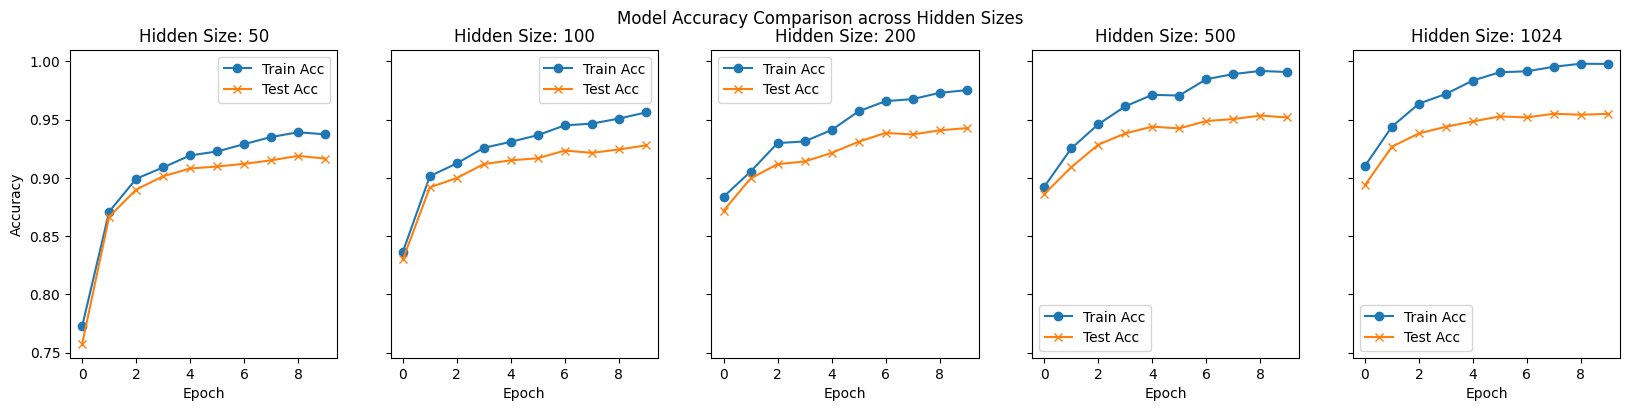

In [11]:
fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(20, 4), sharey=True)
fig.suptitle('Model Accuracy Comparison across Hidden Sizes')

axes[0].set_ylabel("Accuracy")

for i, size in enumerate(hidden_sizes):
    train_acc = hidden_size_train_accs[i]
    test_acc = hidden_size_test_accs[i]

    axes[i].plot(train_acc, label='Train Acc', marker='o')
    axes[i].plot(test_acc, label='Test Acc', marker='x')

    axes[i].set_title(f'Hidden Size: {size}')
    axes[i].set_xlabel('Epoch')
    axes[i].legend()

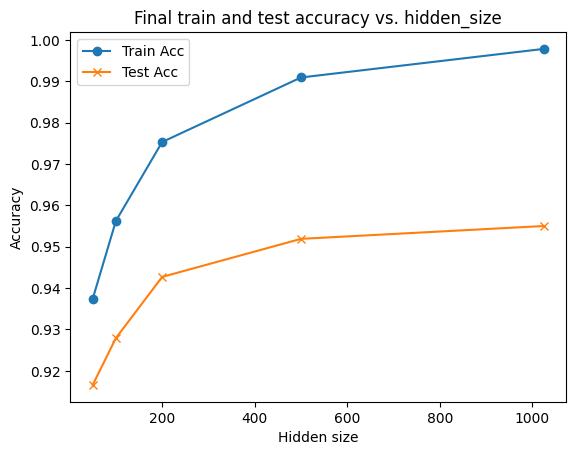

In [12]:
hidden_size_final_train_accs = [_accs[-1] for _accs in hidden_size_train_accs]
hidden_size_final_test_accs = [_accs[-1] for _accs in hidden_size_test_accs]

plt.plot(hidden_sizes, hidden_size_final_train_accs, label='Train Acc', marker='o')
plt.plot(hidden_sizes, hidden_size_final_test_accs, label='Test Acc', marker='x')
plt.xlabel("Hidden size")
plt.ylabel("Accuracy")
plt.title("Final train and test accuracy vs. hidden_size")
plt.legend()

**Question:** does a bigger model lead to worse generalization?

**Answer:** the generalization gap for the bigger model is getting slightly higher (which might imply slighlty worse generalization), however we still do not observe overfitting (both test accuracy and train accuracy are increasing for all values of `hidden_size`)

### Exercise 6: Weight Decay Regularization

The paper argues that explicit regularization (such as weight decay) is **neither necessary nor sufficient** for generalization. Let's test this claim empirically.

Weight decay (L2 regularization) adds a penalty term $\lambda \|\mathbf{w}\|^2$ to the loss, discouraging large weights. The `train_model` function already supports a `weight_decay` parameter that is passed to the Adam optimizer.

We already know from Exercise 2 that the unregularized model generalizes well on true labels. The more interesting question is: **can weight decay prevent the network from memorizing random labels?**

**Task:**
1. Train models with `weight_decay` values `[1e-3, 1e-2, 1e-1]` on **random labels** for 10 epochs each (`hidden_size=1024`)
2. Plot final train accuracy vs. weight decay
3. Discuss: does weight decay prevent memorization? What does this say about the paper's claim?

In [13]:
weight_decays: list[float] = [0, 1e-3, 1e-2, 1e-1]

weight_decays_train_accs = []
weight_decays_test_accs = []

for weight_decay in weight_decays:
  print(f"Training model with weight_decay={weight_decay}")
  print("-"*100)
  _train_accs, _test_accs, _ = train_model(
    train_loader=random_train_loader,
    test_loader=random_test_loader,
    hidden_size=1024,
    num_epochs=10,
    weight_decay=weight_decay
  )

  weight_decays_train_accs.append(_train_accs)
  weight_decays_test_accs.append(_test_accs)

  print("="*100)

Training model with weight_decay=0
----------------------------------------------------------------------------------------------------
Epoch [1/10], Loss: 2.3052, Train Acc: 0.1129, Test Acc: 0.1033
Epoch [2/10], Loss: 2.2982, Train Acc: 0.1369, Test Acc: 0.1048
Epoch [3/10], Loss: 2.2883, Train Acc: 0.1576, Test Acc: 0.0982
Epoch [4/10], Loss: 2.2715, Train Acc: 0.1840, Test Acc: 0.1013
Epoch [5/10], Loss: 2.2386, Train Acc: 0.2079, Test Acc: 0.1035
Epoch [6/10], Loss: 2.1922, Train Acc: 0.2288, Test Acc: 0.0999
Epoch [7/10], Loss: 2.1351, Train Acc: 0.2836, Test Acc: 0.0985
Epoch [8/10], Loss: 2.0481, Train Acc: 0.3399, Test Acc: 0.1042
Epoch [9/10], Loss: 1.9452, Train Acc: 0.3745, Test Acc: 0.1050
Epoch [10/10], Loss: 1.8253, Train Acc: 0.4237, Test Acc: 0.1008
Training model with weight_decay=0.001
----------------------------------------------------------------------------------------------------
Epoch [1/10], Loss: 2.3064, Train Acc: 0.1150, Test Acc: 0.1072
Epoch [2/10], Loss:

**Question:** does weight decay prevent memorization? What does this say about the paper's claim?

**Answer:** weight decay does not *prevent* memorization as we might see the model is still memorizing examples for `weight_decay=1e-3`, however it slows it down. With `weight_decay ∈ {1e-2, 1e-1}`, the regularization is just so strong, that model cannot learn anything - neither specific examples nor general patterns. This supports paper's claim that regularization *is neither neccessary nor by itself sufficient for controlling generalization error*.

Compare our experimental setup and results with those reported in the paper. To what extent do our findings align with the original study? What similarities and discrepancies can be identified?

**Answer:** to my understanding, results align well with the paper findings. My results supports paper's claim that regularization is neither neccessary nor sufficient for controlling generalization. The model without any regularization performed well on true labels (so regularization is not necessary to achieve well generalizing model), however model with regularization (to some extent - only for small values of `weight_decay`) still memorized labels (the memorization was slower, but still occured). In terms of discrepancies, we did not achieve as high memorization as the authors, but that's probably caused by scale - authors used large models, harded datasets and thousands of epochs, we just used few epochs and small network to reproduce these results on a toy problem.

### Discussion Questions

**Q1:** In Exercise 6, you tested whether weight decay can prevent memorization or improve generalization. The paper's central claim is that explicit regularization is "neither necessary nor sufficient" for generalization. Based on your results, do you agree? If an unregularized model already generalizes well on true labels, what role (if any) does regularization actually play in deep learning?

**Answer:** yes, based on my results I agree with author's statement - unregularized model can still generalize and perform well (as we observed in exercise 2), while regularization is not sufficient to prevent memorization (as we observed in exercise 6). However, as paper's authors claim, regularization *might* still improve generalization and in effect is usually used as a tuning parameter to improve model's final performance.

**Q2:** The paper has over 6,000 citations, yet at its core it is based on a very simple experiment: training on random labels. Why do you think something so straightforward ended up having such a big impact on the field? What does this tell us about the value of empirical work vs. theoretical work in machine learning?

**Answer:** despite paper's simplicity, the results exposed fundamental gap in classical generalization theory and showed how these traditional approches fail to explain why large models generalize well in practice. This tells us that good empirical analysis might be more powerful than complex theoretical work.